In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Ensure the src directory is accessible for imports
sys.path.append(os.path.abspath('..'))
from src.cbadvai_models import FrankHallOrdinalClassifier, evaluate_ordinal_model

In [2]:
# Load the dataset
file_path = '../data/raw/Database paper.xlsx'
df = pd.read_excel(file_path)

# PREPROCESSING CORRECTION
# Remap 'Policy_Stu' from 1(Yes)/2(No) to 1(Yes)/0(No) for proper coefficient interpretation
if 2 in df['Policy_Stu'].values:
    df['Policy_Stu'] = df['Policy_Stu'].map({1: 1, 2: 0})

# FEATURE SELECTION: Strictly aligning with the Research Question
selected_features = [
    # Internal Behaviors
    'Study_Methods', 'Time_Studying', 'Time_Friends', 'Time_SocicalMedia', 'Adapt_Learning_Uni',
    # External Support
    'Policy_Stu', 'SupportOf_Uni', 'SupportOf_Lec', 'Facilitie_Uni', 'Quality_Lecturer', 'TrainingCurriculum'
]

X = df[selected_features]
y = df['GPA']

# 80/20 Stratified Holdout Split to isolate testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    stratify=y, 
    random_state=42
)

# Initialize Stratified K-Fold for development loop (k=5)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Training Set Size: {X_train.shape[0]} observations")
print(f"Isolated Test Set Size: {X_test.shape[0]} observations")
print(f"Selected Feature Space: {X.shape[1]} variables directly tied to the RQ.")

Training Set Size: 1736 observations
Isolated Test Set Size: 434 observations
Selected Feature Space: 11 variables directly tied to the RQ.


In [3]:
print("Tuning Model 1: Ordinal Logistic Regression with SMOTE...")

ordinal_lr = FrankHallOrdinalClassifier(solver='saga')
lr_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', ordinal_lr)
])

param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l1', 'l2']
}

grid_lr = GridSearchCV(lr_pipeline, param_grid_lr, scoring='f1_macro', cv=skf, n_jobs=-1)
grid_lr.fit(X_train, y_train)

print("Tuning Complete.")

Tuning Model 1: Ordinal Logistic Regression with SMOTE...


C:\Users\Axl Roel\Documents\1253\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Axl Roel\Documents\1253\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Axl Roel\Documents\1253

Tuning Complete.


In [4]:
print("Tuning Model 2: Neural Network (MLP) with SMOTE...")

mlp = MLPClassifier(solver='adam', early_stopping=True, n_iter_no_change=15, max_iter=1500, random_state=42)
mlp_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', mlp)
])

param_grid_mlp = {
    'classifier__hidden_layer_sizes': [(64, 32), (32, 16)],
    'classifier__alpha': [0.0001, 0.01]
}

grid_mlp = GridSearchCV(mlp_pipeline, param_grid_mlp, scoring='f1_macro', cv=skf, n_jobs=-1)
grid_mlp.fit(X_train, y_train)

print("Tuning Complete.")

Tuning Model 2: Neural Network (MLP) with SMOTE...
Tuning Complete.


In [5]:
print("Tuning Model 3: Random Forest with SMOTE...")

rf = RandomForestClassifier(random_state=42)
rf_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', rf)
])

param_grid_rf = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(rf_pipeline, param_grid_rf, scoring='f1_macro', cv=skf, n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Tuning Complete.")

Tuning Model 3: Random Forest with SMOTE...
Tuning Complete.


In [6]:
# Compare models on the Validation Folds before touching the Test set
print("=== Cross-Validation Phase Comparison (Macro F1) ===")
print(f"Ordinal Logistic Regression CV Score: {grid_lr.best_score_:.4f} (Params: {grid_lr.best_params_})")
print(f"Neural Network (MLP) CV Score:        {grid_mlp.best_score_:.4f} (Params: {grid_mlp.best_params_})")
print(f"Random Forest CV Score:               {grid_rf.best_score_:.4f} (Params: {grid_rf.best_params_})\n")

=== Cross-Validation Phase Comparison (Macro F1) ===
Ordinal Logistic Regression CV Score: 0.2278 (Params: {'classifier__C': 0.01, 'classifier__penalty': 'l2'})
Neural Network (MLP) CV Score:        0.2338 (Params: {'classifier__alpha': 0.0001, 'classifier__hidden_layer_sizes': (64, 32)})
Random Forest CV Score:               0.3254 (Params: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100})



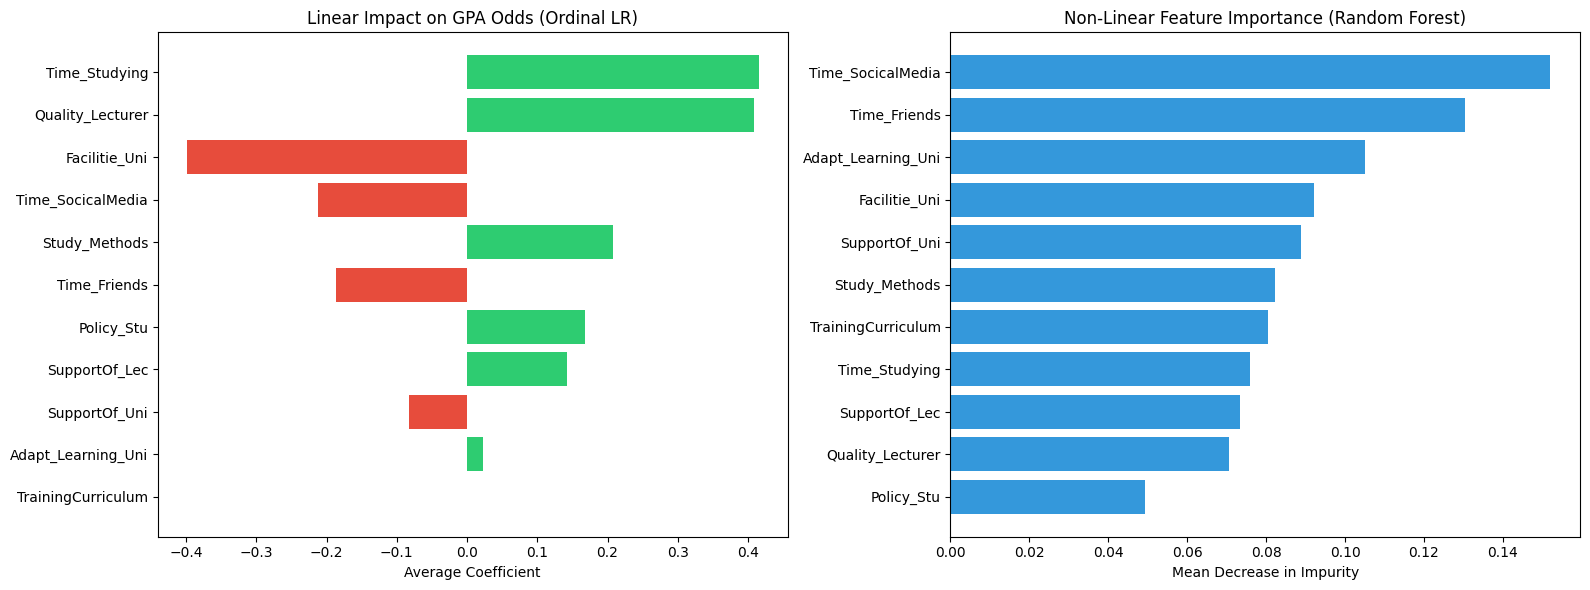

In [7]:
best_lr = grid_lr.best_estimator_.named_steps['classifier']
best_rf = grid_rf.best_estimator_.named_steps['classifier']
feature_names = X_train.columns

# Extracting OLR Weights (Averaged across binary thresholds)
avg_coefficients = np.mean([model.coef_[0] for model in best_lr.models.values()], axis=0)
olr_weights = pd.DataFrame({'Feature': feature_names, 'Weight': avg_coefficients})
olr_weights = olr_weights.sort_values(by='Weight', key=abs, ascending=True)

# Extracting Random Forest Feature Importances
rf_importances = pd.DataFrame({'Feature': feature_names, 'Importance': best_rf.feature_importances_})
rf_importances = rf_importances.sort_values(by='Importance', ascending=True)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Ordinal Logistic Regression Coefficients
axes[0].barh(olr_weights['Feature'], olr_weights['Weight'], 
             color=np.where(olr_weights['Weight'] > 0, '#2ecc71', '#e74c3c'))
axes[0].set_title('Linear Impact on GPA Odds (Ordinal LR)')
axes[0].set_xlabel('Average Coefficient')

# Subplot 2: Random Forest Feature Importances
axes[1].barh(rf_importances['Feature'], rf_importances['Importance'], color='#3498db')
axes[1].set_title('Non-Linear Feature Importance (Random Forest)')
axes[1].set_xlabel('Mean Decrease in Impurity')

plt.tight_layout()
plt.show()

In [8]:
# Extract best MLP estimator to go along with LR and RF
best_mlp = grid_mlp.best_estimator_.named_steps['classifier']

# Generate test predictions
y_pred_lr = best_lr.predict(X_test)
y_pred_mlp = best_mlp.predict(X_test)
y_pred_rf = best_rf.predict(X_test)

# Final Unbiased Evaluation on Isolated Test Set
results_lr = evaluate_ordinal_model(y_test, y_pred_lr, model_name="Ordinal Logistic Regression (SMOTE)")
results_mlp = evaluate_ordinal_model(y_test, y_pred_mlp, model_name="Multi-Layer Perceptron (SMOTE)")
results_rf = evaluate_ordinal_model(y_test, y_pred_rf, model_name="Random Forest (SMOTE)")

--- Evaluation Metrics: Ordinal Logistic Regression (SMOTE) ---
Macro-Averaged F1-Score: 0.2244
Mean Absolute Error (MAE): 1.1475

Confusion Matrix:
[[ 5  2  1  6  1]
 [ 4 11  2  3  2]
 [44 59 75 28 32]
 [28 19 30 31 30]
 [ 3  2  4  7  5]]
----------------------------------------
--- Evaluation Metrics: Multi-Layer Perceptron (SMOTE) ---
Macro-Averaged F1-Score: 0.2202
Mean Absolute Error (MAE): 1.0922

Confusion Matrix:
[[ 3  2  2  4  4]
 [ 2  5  2  8  5]
 [30 30 66 80 32]
 [22 14 22 53 27]
 [ 2  3  1  9  6]]
----------------------------------------
--- Evaluation Metrics: Random Forest (SMOTE) ---
Macro-Averaged F1-Score: 0.3139
Mean Absolute Error (MAE): 0.7880

Confusion Matrix:
[[  3   0   8   4   0]
 [  2   4  10   5   1]
 [ 16  17 126  54  25]
 [ 13   9  43  60  13]
 [  0   2   7   3   9]]
----------------------------------------
